# Explore here

In [225]:
import pandas as pd

# Load the CSV file from the URL
url = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
wine_data = pd.read_csv(url, sep = ';')

# Configurar pandas para mostrar todas las filas y columnas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Display the first few rows of the dataframe
wine_data.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [226]:
wine_data.shape

(1599, 12)

In [227]:
# Definir la función quality_to_label
def quality_to_label(q):
    if q <= 4:
        return 0  # baja
    elif q <= 6:
        return 1  # media
    else:
        return 2  # alta

# Aplicar la función a la columna 'quality' para crear la columna 'label'
wine_data['label'] = wine_data['quality'].apply(quality_to_label)

# Mostrar las primeras filas para verificar
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


In [228]:
wine_data = wine_data.drop(columns=['quality'])

# Verificar las primeras filas después de eliminar la columna
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,1


In [229]:
wine_data['label'].value_counts()

label
1    1319
2     217
0      63
Name: count, dtype: int64

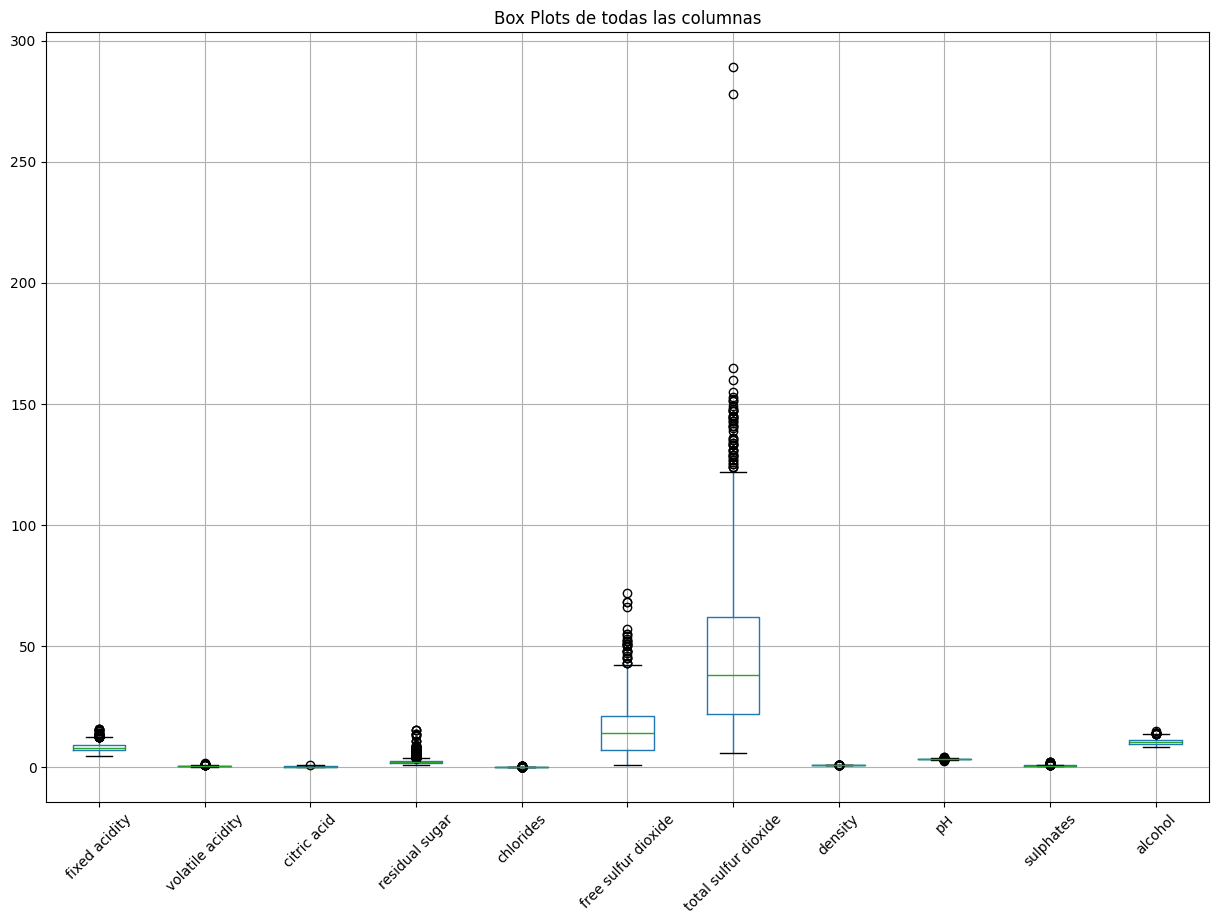

In [230]:
import matplotlib.pyplot as plt

# Crear box plots para todas las columnas numéricas
wine_data.drop(columns=['label']).boxplot(figsize=(15, 10), rot=45)
plt.title("Box Plots de todas las columnas")
plt.show()

In [231]:
unique_labels = wine_data['label'].unique()
print("Valores únicos en 'label':", unique_labels)

Valores únicos en 'label': [1 2 0]


In [232]:
# Definir los rangos aceptables para cada columna
criteria = {
    'fixed acidity': (6.0, 14.0),
    'volatile acidity': (0.12, 1.1),
    'citric acid': (0.0, 0.9),
    'residual sugar': (0.9, 13.0),
    'chlorides': (0.01, 0.15),
    'free sulfur dioxide': (5, 60),
    'total sulfur dioxide': (10, 200),
    'density': (0.9900, 1.0020),
    'pH': (3.0, 3.9),
    'sulphates': (0.3, 1.3),
    'alcohol': (9.0, 14.5)
}

# Contador de filas iniciales
initial_rows = wine_data.shape[0]

# Filtrar los datos para mantener solo las filas dentro de los rangos aceptables
for column, (min_val, max_val) in criteria.items():
    wine_data = wine_data[(wine_data[column] >= min_val) & (wine_data[column] <= max_val)]

# Contador de filas finales
final_rows = wine_data.shape[0]

# Calcular cuántas filas se eliminaron
rows_removed = initial_rows - final_rows
print(f"Se eliminaron {rows_removed} filas.")


Se eliminaron 263 filas.


In [233]:
from sklearn.utils import resample

# Separar el dataset en tres subconjuntos según las etiquetas
label_0 = wine_data[wine_data['label'] == 0]
label_1 = wine_data[wine_data['label'] == 1]
label_2 = wine_data[wine_data['label'] == 2]

# Determinar el tamaño máximo para balancear
max_size = max(len(label_0), len(label_1), len(label_2))

# Aumentar las etiquetas menos representadas con datos sintéticos
label_0_balanced = resample(label_0, replace=True, n_samples=max_size, random_state=42)
label_1_balanced = resample(label_1, replace=True, n_samples=max_size, random_state=42)
label_2_balanced = resample(label_2, replace=True, n_samples=max_size, random_state=42)

# Combinar los datasets balanceados
wine_data = pd.concat([label_0_balanced, label_1_balanced, label_2_balanced])

# Mezclar las filas para evitar cualquier orden
wine_data = wine_data.sample(frac=1, random_state=42).reset_index(drop=True)

# Verificar el balanceo
print(wine_data['label'].value_counts())

label
2    1123
0    1123
1    1123
Name: count, dtype: int64


In [234]:
# Muestra 20 filas al azar para cada etiqueta
sampled_data = wine_data.groupby('label').apply(lambda x: x.sample(n=20, random_state=42)).reset_index(drop=True)

# Mostrar las primeras filas del resultado
sampled_data.head(60)

/tmp/ipykernel_6387/2589333810.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_data = wine_data.groupby('label').apply(lambda x: x.sample(n=20, random_state=42)).reset_index(drop=True)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,label
0,7.3,0.980,0.05,2.10,0.061,20.0,49.0,0.99705,3.31,0.55,9.7,0
1,7.0,0.975,0.04,2.00,0.087,12.0,67.0,0.99565,3.35,0.60,9.4,0
2,8.1,0.730,0.00,2.50,0.081,12.0,24.0,0.99798,3.38,0.46,9.6,0
3,7.1,0.840,0.02,4.40,0.096,5.0,13.0,0.99700,3.41,0.57,11.0,0
4,8.8,0.610,0.30,2.80,0.088,17.0,46.0,0.99760,3.26,0.51,9.3,0
5,7.3,0.980,0.05,2.10,0.061,20.0,49.0,0.99705,3.31,0.55,9.7,0
6,6.2,0.785,0.00,2.10,0.060,6.0,13.0,0.99664,3.59,0.61,10.0,0
7,6.2,0.785,0.00,2.10,0.060,6.0,13.0,0.99664,3.59,0.61,10.0,0
8,8.4,0.635,0.36,2.00,0.089,15.0,55.0,0.99745,3.31,0.57,10.4,0
9,7.5,0.380,0.48,2.60,0.073,22.0,84.0,0.99720,3.32,0.70,9.6,0


In [235]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np


# Separar las variables independientes (X) del objetivo (y)
X = wine_data.drop(columns=['label'])
y = wine_data['label']

# Dividir en conjunto de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar el modelo con un valor de k inicial
k_initial = 5
knn = KNeighborsClassifier(n_neighbors=k_initial)
knn.fit(X_train_scaled, y_train)


# Crear las predicciones para el conjunto de prueba
y_pred = knn.predict(X_test_scaled)

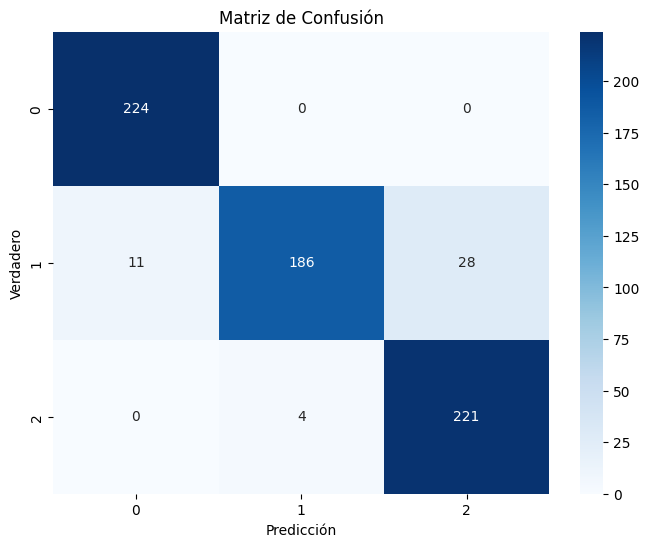

In [236]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Crear la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Graficar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión')
plt.show()

In [237]:
print(classification_report(y_test, y_pred, target_names=['Baja', 'Media', 'Alta']))

              precision    recall  f1-score   support

        Baja       0.95      1.00      0.98       224
       Media       0.98      0.83      0.90       225
        Alta       0.89      0.98      0.93       225

    accuracy                           0.94       674
   macro avg       0.94      0.94      0.93       674
weighted avg       0.94      0.94      0.93       674



In [238]:
def predict_wine_quality(features):
    features_scaled = scaler.transform([features])
    pred = knn.predict(features_scaled)[0]
    if pred == 0:
        return "Este vino probablemente sea de baja calidad 🍷"
    elif pred == 1:
        return "Este vino probablemente sea de calidad media 🍷"
    else:
        return "Este vino probablemente sea de alta calidad 🍷"

In [239]:
resultado = predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076,
                                  11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])
print("\nPredicción de ejemplo:", resultado)


Predicción de ejemplo: Este vino probablemente sea de calidad media 🍷


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
